# MSML606 HW-3

### AI tools (ChatGPT, Claude) were used for general understanding and clarification of concepts (trees, stacks).

## Part I: Hash table implementation

## Problem 1. Implement a hash table.

In [1]:
import time
import random
import matplotlib.pyplot as plt

class HashMap:
    def __init__(self, size=101):
        self.size = size
        self.table = []
        self.count = 0
        self.hash_method = "division"
        for _ in range(size):
            self.table.append([])   # each is a list

    def _key_to_int(self, key):
        # convert key into a number
        if type(key) == int:
            return abs(key)
        elif type(key) == str:
            total = 0
            for ch in key:
                total = total + ord(ch)
            return total
        else:
            # edge case
            text = str(key)
            total = 0
            for ch in text:
                total = total + ord(ch)
            return total

    # retrieve value
    def search(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        for pair in chain:
            if pair[0] == key:
                return pair[1]
        return None

    # insert into the hash table
    def insert(self, key, value):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        # update if key already exists
        for i in range(len(chain)):
            if chain[i][0] == key:
                chain[i] = (key, value)
                return
        chain.append((key, value))
        self.count += 1

    # remove the key value pair from table
    def delete(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]

        for i in range(len(chain)):
            if chain[i][0] == key:
                del chain[i]
                self.count -= 1
                return True

        return False

    def dynamicResizing(self):
        pass

    # hashing methods
    def _hash(self, key, method="division"):
        num = self._key_to_int(key)

        # division
        if method == "division":
            return num % self.size

        # multiplication
        elif method == "multiplication":
            a = 0.618
            frac = (num * a) % 1
            return int(self.size * frac)

        # default case
        return num % self.size

    def load_factor(self):
        return self.count / self.size

    def average_chain_length(self):
        total = 0
        for chain in self.table:
            total += len(chain)
        return total / self.size

    def max_chain_length(self):
        longest = 0
        for chain in self.table:
            if len(chain) > longest:
                longest = len(chain)
        return longest



## Problem 2. Performance Analysis

Search apple: 10
Search banana: 20
After delete banana: None
Method: division | Size: 101 | Load Factor: 0.25 | Success Time: 4.4583999624592253e-07 | Fail Time: 3.0640000204584793e-07
Method: division | Size: 101 | Load Factor: 0.5 | Success Time: 5.716199984817649e-07 | Fail Time: 2.8433999887056417e-07
Method: division | Size: 101 | Load Factor: 0.75 | Success Time: 3.2453333460580324e-07 | Fail Time: 2.926800001053683e-07
Method: division | Size: 101 | Load Factor: 1.0 | Success Time: 3.2995999958984613e-07 | Fail Time: 2.9494000045815485e-07
Method: division | Size: 101 | Load Factor: 1.25 | Success Time: 3.3788999985517877e-07 | Fail Time: 4.109999997581326e-07


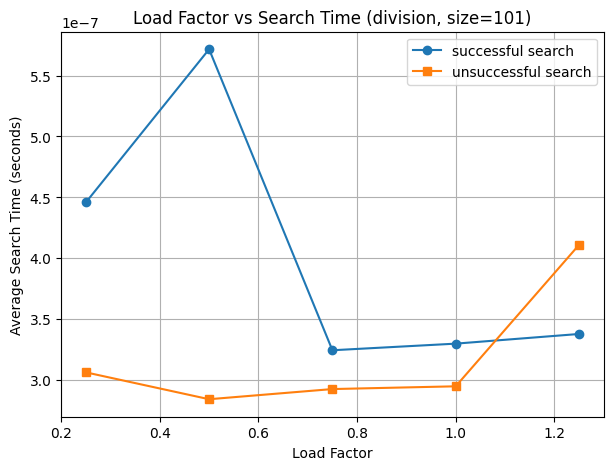

Method: division | Size: 503 | Load Factor: 0.25 | Success Time: 6.160199995974835e-07 | Fail Time: 4.93700000561148e-07
Method: division | Size: 503 | Load Factor: 0.5 | Success Time: 5.752899994604376e-07 | Fail Time: 4.1152999983751217e-07
Method: division | Size: 503 | Load Factor: 0.75 | Success Time: 4.0239999975710817e-07 | Fail Time: 3.264899999066984e-07
Method: division | Size: 503 | Load Factor: 1.0 | Success Time: 3.622199994879338e-07 | Fail Time: 3.279199995631643e-07
Method: division | Size: 503 | Load Factor: 1.25 | Success Time: 3.6869999917144017e-07 | Fail Time: 3.3515999916744474e-07


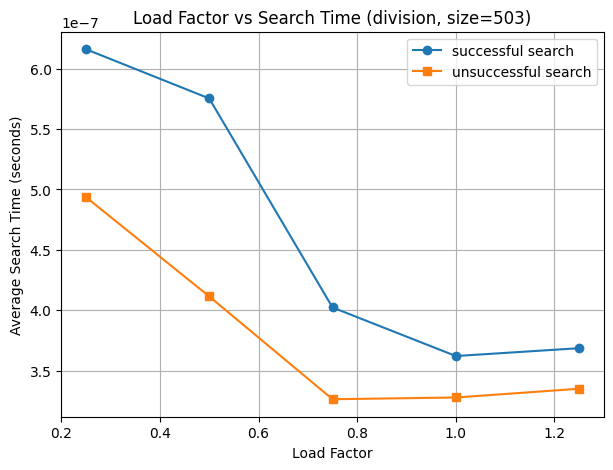

Method: division | Size: 1009 | Load Factor: 0.25 | Success Time: 3.3823999956439366e-07 | Fail Time: 3.1178999961412044e-07
Method: division | Size: 1009 | Load Factor: 0.5 | Success Time: 3.5564000086196754e-07 | Fail Time: 5.997099992782751e-07
Method: division | Size: 1009 | Load Factor: 0.75 | Success Time: 3.533300002800388e-07 | Fail Time: 3.173400000378024e-07
Method: division | Size: 1009 | Load Factor: 1.0 | Success Time: 4.0310000031240635e-07 | Fail Time: 3.2786000019768836e-07
Method: division | Size: 1009 | Load Factor: 1.25 | Success Time: 4.62770000240198e-07 | Fail Time: 3.8895999978194594e-07


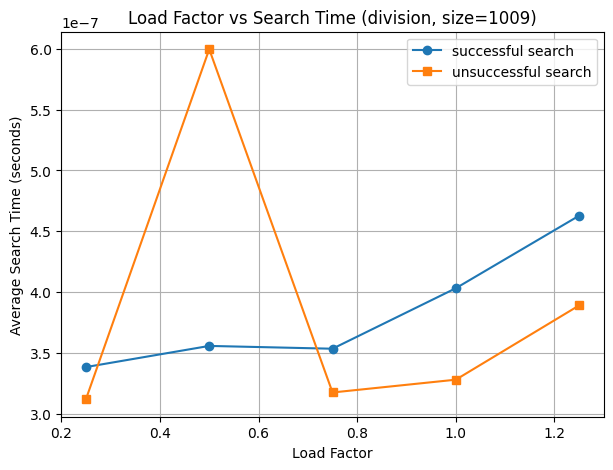

Method: multiplication | Size: 101 | Load Factor: 0.25 | Success Time: 8.313600028486689e-07 | Fail Time: 6.689199972242931e-07
Method: multiplication | Size: 101 | Load Factor: 0.5 | Success Time: 6.789000008211587e-07 | Fail Time: 5.89779999700113e-07
Method: multiplication | Size: 101 | Load Factor: 0.75 | Success Time: 5.965200004235763e-07 | Fail Time: 5.795733341074083e-07
Method: multiplication | Size: 101 | Load Factor: 1.0 | Success Time: 8.491300002333446e-07 | Fail Time: 5.929300004936522e-07
Method: multiplication | Size: 101 | Load Factor: 1.25 | Success Time: 6.176900001264585e-07 | Fail Time: 2.5997500006269547e-06


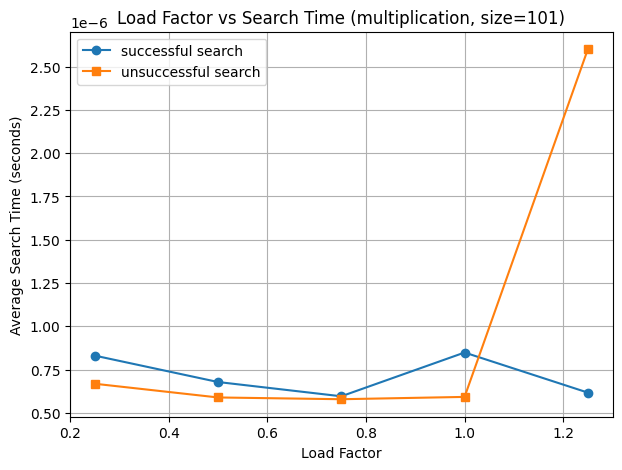

Method: multiplication | Size: 503 | Load Factor: 0.25 | Success Time: 1.394700000219018e-06 | Fail Time: 1.100709999946048e-06
Method: multiplication | Size: 503 | Load Factor: 0.5 | Success Time: 1.2266400005955803e-06 | Fail Time: 6.1113599997497655e-06
Method: multiplication | Size: 503 | Load Factor: 0.75 | Success Time: 1.2738899999931163e-06 | Fail Time: 1.2515599996731907e-06
Method: multiplication | Size: 503 | Load Factor: 1.0 | Success Time: 1.1103999997885693e-06 | Fail Time: 5.124520000663324e-06
Method: multiplication | Size: 503 | Load Factor: 1.25 | Success Time: 1.2867399993865548e-06 | Fail Time: 1.1632200005351479e-06


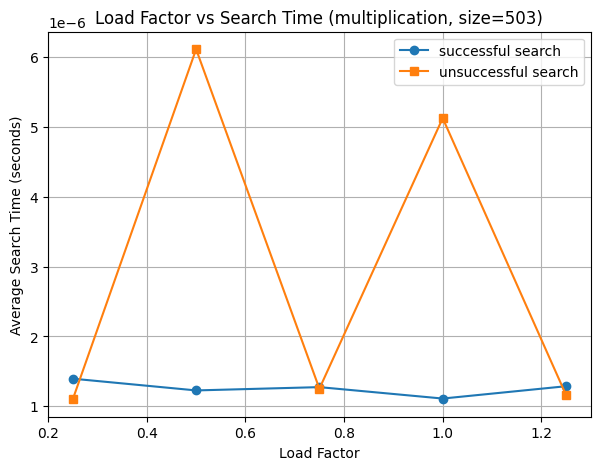

Method: multiplication | Size: 1009 | Load Factor: 0.25 | Success Time: 6.553499997608014e-07 | Fail Time: 1.648610000302142e-06
Method: multiplication | Size: 1009 | Load Factor: 0.5 | Success Time: 8.026299997254682e-07 | Fail Time: 6.59720000157904e-07
Method: multiplication | Size: 1009 | Load Factor: 0.75 | Success Time: 6.396399999175629e-07 | Fail Time: 7.328700007747102e-07
Method: multiplication | Size: 1009 | Load Factor: 1.0 | Success Time: 3.414719999454974e-06 | Fail Time: 8.640400005788251e-07
Method: multiplication | Size: 1009 | Load Factor: 1.25 | Success Time: 6.975899998451496e-07 | Fail Time: 7.358499999554624e-07


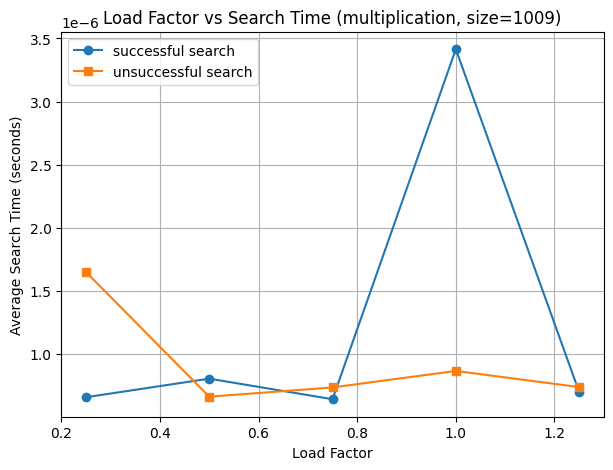


Distribution: uniform
Method: division
Successful search time: 1.0717999998632877e-06
Unsuccessful search time: 7.597400008307886e-07
Average chain length: 0.7495029821073559
Maximum chain length: 4

Distribution: skewed
Method: division
Successful search time: 6.352900004458207e-07
Unsuccessful search time: 5.951699995421222e-07
Average chain length: 0.341948310139165
Maximum chain length: 3

Distribution: sequential
Method: division
Successful search time: 1.9215600002553403e-06
Unsuccessful search time: 2.6038400005745643e-06
Average chain length: 0.7495029821073559
Maximum chain length: 1


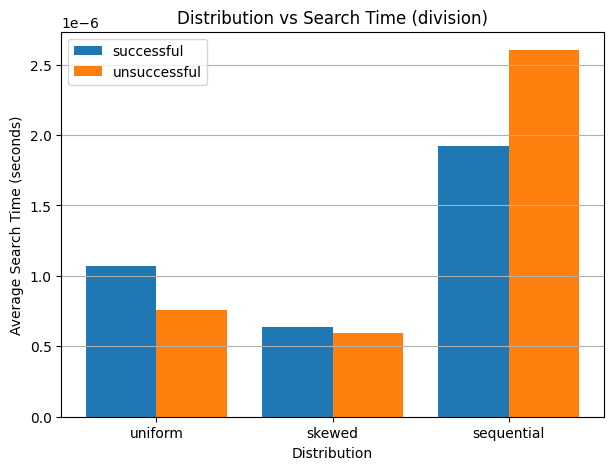

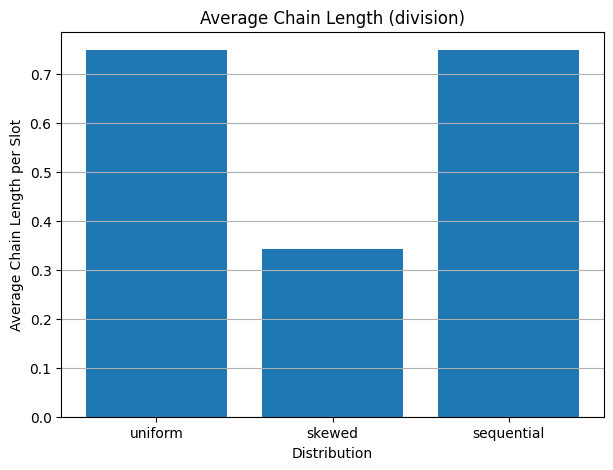

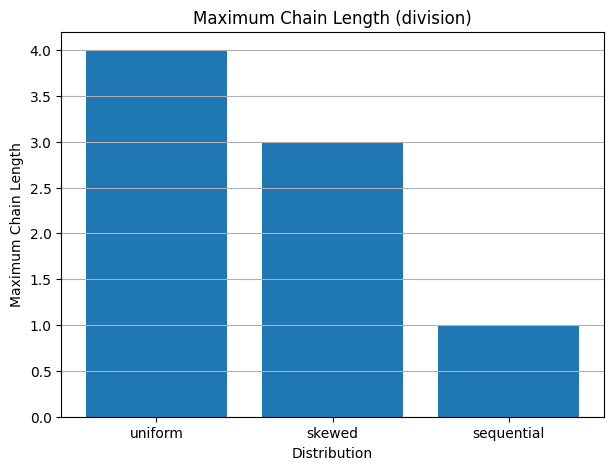


Distribution: uniform
Method: multiplication
Successful search time: 6.414900008167023e-07
Unsuccessful search time: 6.073299994113768e-07
Average chain length: 0.7495029821073559
Maximum chain length: 4

Distribution: skewed
Method: multiplication
Successful search time: 5.89769999805867e-07
Unsuccessful search time: 6.050399997548084e-07
Average chain length: 0.32803180914512925
Maximum chain length: 3

Distribution: sequential
Method: multiplication
Successful search time: 5.780499998309097e-07
Unsuccessful search time: 6.095999992794532e-07
Average chain length: 0.7495029821073559
Maximum chain length: 1


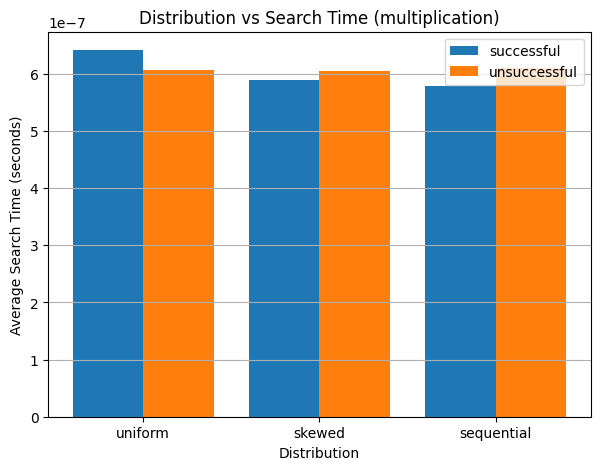

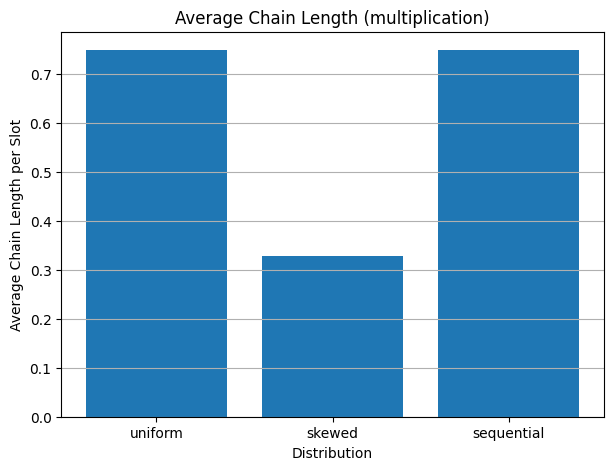

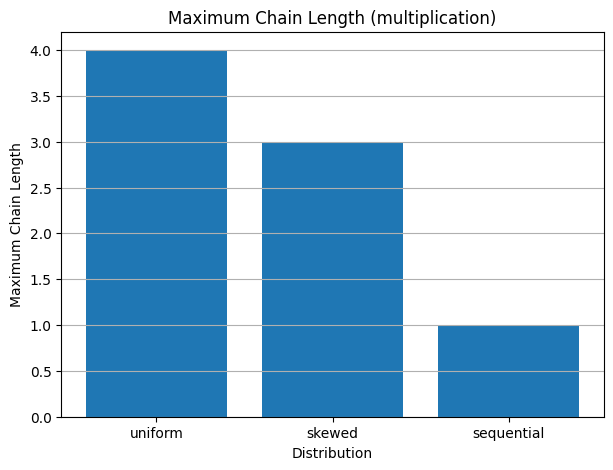

In [6]:
def generate_keys(distribution, n):
    keys = []

    if distribution == "uniform":
        for _ in range(n):
            keys.append(random.randint(1, 1000000))

    elif distribution == "skewed":
        for _ in range(n):
            if random.random() < 0.8:
                keys.append(random.randint(1, 100))
            else:
                keys.append(random.randint(101, 1000000))

    elif distribution == "sequential":
        for i in range(n):
            keys.append(i + 1)

    return keys


def measure_search_time(hashmap, keys):
    start = time.perf_counter()

    for key in keys:
        hashmap.search(key)

    end = time.perf_counter()

    if len(keys) == 0:
        return 0

    return (end - start) / len(keys)


def run_experiments():

    table_sizes = [101, 503, 1009]
    load_factors = [0.25, 0.50, 0.75, 1.0, 1.25]
    methods = ["division", "multiplication"]
    # Experiment 1
    # Load factor vs search time
    for method in methods:
        for size in table_sizes:
            good_times = []
            bad_times = []

            for lf in load_factors:
                h = HashMap(size)
                h.hash_method = method

                n = int(size * lf)
                keys = generate_keys("uniform", n)

                for key in keys:
                    h.insert(key, key * 10)

                # successful search
                if len(keys) > 100:
                    good_keys = random.sample(keys, 100)
                else:
                    good_keys = keys[:]

                # unsuccessful search
                bad_keys = []
                while len(bad_keys) < len(good_keys):
                    x = random.randint(2000000, 3000000)
                    bad_keys.append(x)

                t_good = measure_search_time(h, good_keys)
                t_bad = measure_search_time(h, bad_keys)

                good_times.append(t_good)
                bad_times.append(t_bad)

                print("Method:", method,
                      "| Size:", size,
                      "| Load Factor:", round(lf, 2),
                      "| Success Time:", t_good,
                      "| Fail Time:", t_bad)

            plt.figure(figsize=(7, 5))
            plt.plot(load_factors, good_times, marker='o', label='successful search')
            plt.plot(load_factors, bad_times, marker='s', label='unsuccessful search')
            plt.xlabel("Load Factor")
            plt.ylabel("Average Search Time (seconds)")
            plt.title("Load Factor vs Search Time (" + method + ", size=" + str(size) + ")")
            plt.legend()
            plt.grid(True)
            plt.show()

    # Experiment 2
    # Key distribution comparisons
    fixed_size = 503
    fixed_load_factor = 0.75
    n = int(fixed_size * fixed_load_factor)

    distributions = ["uniform", "skewed", "sequential"]

    for method in methods:
        success_result = []
        fail_result = []
        avg_chain_result = []
        max_chain_result = []

        for dist in distributions:
            h = HashMap(fixed_size)
            h.hash_method = method

            keys = generate_keys(dist, n)

            for key in keys:
                h.insert(key, key * 10)

            if len(keys) > 100:
                good_keys = random.sample(keys, 100)
            else:
                good_keys = keys[:]

            bad_keys = []
            while len(bad_keys) < len(good_keys):
                x = random.randint(2000000, 3000000)
                bad_keys.append(x)

            t_good = measure_search_time(h, good_keys)
            t_bad = measure_search_time(h, bad_keys)

            success_result.append(t_good)
            fail_result.append(t_bad)
            avg_chain_result.append(h.average_chain_length())
            max_chain_result.append(h.max_chain_length())

            print("\nDistribution:", dist)
            print("Method:", method)
            print("Successful search time:", t_good)
            print("Unsuccessful search time:", t_bad)
            print("Average chain length:", h.average_chain_length())
            print("Maximum chain length:", h.max_chain_length())

        # plot search time for distributions
        x = range(len(distributions))

        plt.figure(figsize=(7, 5))
        plt.bar([i - 0.2 for i in x], success_result, width=0.4, label='successful')
        plt.bar([i + 0.2 for i in x], fail_result, width=0.4, label='unsuccessful')
        plt.xticks(list(x), distributions)
        plt.xlabel("Distribution")
        plt.ylabel("Average Search Time (seconds)")
        plt.title("Distribution vs Search Time (" + method + ")")
        plt.legend()
        plt.grid(True, axis='y')
        plt.show()

        # plot chain lengths
        plt.figure(figsize=(7, 5))
        plt.bar(distributions, avg_chain_result)
        plt.xlabel("Distribution")
        plt.ylabel("Average Chain Length per Slot")
        plt.title("Average Chain Length (" + method + ")")
        plt.grid(True, axis='y')
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.bar(distributions, max_chain_result)
        plt.xlabel("Distribution")
        plt.ylabel("Maximum Chain Length")
        plt.title("Maximum Chain Length (" + method + ")")
        plt.grid(True, axis='y')
        plt.show()


# example test
if __name__ == "__main__":
    h = HashMap(11)
    h.hash_method = "division"

    h.insert("apple", 10)
    h.insert("banana", 20)
    h.insert("orange", 30)

    print("Search apple:", h.search("apple"))
    print("Search banana:", h.search("banana"))

    h.delete("banana")
    print("After delete banana:", h.search("banana"))

    run_experiments()